# House Prices Prediction using Advanced Regression Techniques
### 5th Semester IT Engineering - Data Science Project

**Project Objective:**
The objective of this project is to predict residential house sale prices in Ames, Iowa, using the Kaggle House Prices dataset. We implement a complete machine learning pipeline in Python, comparing L2-regularized linear model (**Ridge**) and L1-regularized linear model (**Lasso**).

**Key Concepts Covered:**
1. **Exploratory Data Analysis (EDA):** Checking feature distributions, correlation analysis, missing value detection, and target variable transformation.
2. **Data Preprocessing & Cleaning:** Handling missing data using median/most-frequent strategies, scaling numerical features, and encoding categorical variables using One-Hot Encoding via Scikit-Learn's `Pipeline` and `ColumnTransformer`.
3. **Regression Modeling:** Implementation of Ridge and Lasso Regression.
4. **Performance Evaluation:** Quantifying predictive power using Root Mean Squared Error (RMSE) and $R^2$ Score on a validation set.
5. **Model Persistence:** Saving the best-performing model as a serialized file (`best_house_price_model.pkl`) and generating predictions for the Kaggle test set (`submission.csv`).

## 1. Import Libraries
In this section, we import all the necessary Python libraries for data analysis, scientific computation, data visualization, and machine learning.
- **Pandas & NumPy** for data manipulation and array processing.
- **Matplotlib & Seaborn** for descriptive visualizations.
- **Scikit-Learn** for preprocessing, pipeline construction, regression algorithms, and metrics evaluation.

In [34]:
# Import core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Import scikit-learn preprocessing and pipeline tools
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import regression models
from sklearn.linear_model import Ridge, Lasso

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style and figures parameters for professional aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset
We load the Ames Housing dataset from the local `data/` directory. 
- `train.csv` contains both features and the target variable `SalePrice`, which we use to train and validate our models.
- `test.csv` contains only features, for which we must predict the `SalePrice`.

In [35]:
# Define path to the datasets
train_path = 'data/train.csv'
test_path = 'data/test.csv'

# Verify files exist
if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError("Make sure train.csv and test.csv are located in the local 'data/' folder.")

# Load the datasets using pandas
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Display dataset dimensions (shapes)
print(f"Training dataset shape: {train.shape} (rows, columns)")
print(f"Testing dataset shape:  {test.shape} (rows, columns)")

# Preview the first 5 rows of the training dataset
train.head()

Training dataset shape: (1460, 81) (rows, columns)
Testing dataset shape:  (1459, 80) (rows, columns)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Analysis (EDA)
Exploratory Data Analysis is a crucial step in understanding the structure, characteristics, and patterns of our data. 

In this section, we will:
1. Display general information about the dataset.
2. Check for missing values in columns.
3. Show summary descriptive statistics for numerical variables.
4. Visualize the distribution of the target variable `SalePrice` before and after log-transformation.
5. Generate a correlation heatmap to identify the strongest linear relationships with `SalePrice`.
6. Compute the skewness of numerical features.

In [36]:
# 3.1 Display dataset structure, column data types, and non-null counts
print("=== Training Dataset Info ===")
train.info()

=== Training Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 no

In [37]:
# 3.2 Calculate the number and percentage of missing values per column
missing_counts = train.isnull().sum()
missing_percent = 100 * train.isnull().sum() / len(train)

# Create a DataFrame to view columns with missing values
missing_data = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percent
})

# Display features with missing values sorted in descending order
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print(f"Total columns with missing values: {len(missing_data)}")
print("\nTop 15 columns with most missing values:")
print(missing_data.head(15))

Total columns with missing values: 19

Top 15 columns with most missing values:
              Missing Count  Percentage (%)
PoolQC                 1453       99.520548
MiscFeature            1406       96.301370
Alley                  1369       93.767123
Fence                  1179       80.753425
MasVnrType              872       59.726027
FireplaceQu             690       47.260274
LotFrontage             259       17.739726
GarageType               81        5.547945
GarageYrBlt              81        5.547945
GarageFinish             81        5.547945
GarageQual               81        5.547945
GarageCond               81        5.547945
BsmtFinType2             38        2.602740
BsmtExposure             38        2.602740
BsmtFinType1             37        2.534247


In [38]:
# 3.3 Generate summary statistics for numerical features
print("=== Descriptive Statistics for Numerical Features ===")
train.describe()

=== Descriptive Statistics for Numerical Features ===


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


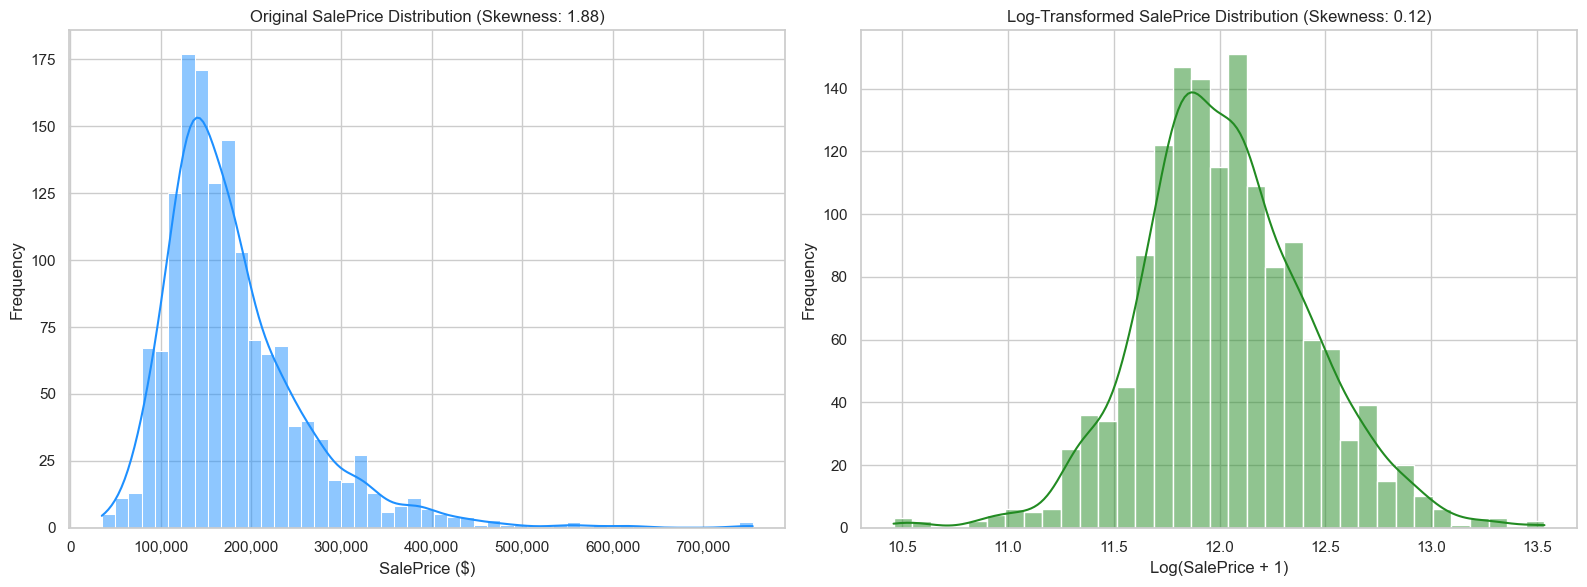

In [39]:
# 3.4 Visualize the target variable SalePrice distribution (Original vs Log-Transformed)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Raw SalePrice distribution
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='dodgerblue')
axes[0].set_title(f"Original SalePrice Distribution (Skewness: {train['SalePrice'].skew():.2f})", fontsize=12)
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Frequency")
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Plot 2: Log-transformed SalePrice distribution (y = log(1 + x))
log_saleprice = np.log1p(train['SalePrice'])
sns.histplot(log_saleprice, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title(f"Log-Transformed SalePrice Distribution (Skewness: {log_saleprice.skew():.2f})", fontsize=12)
axes[1].set_xlabel("Log(SalePrice + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

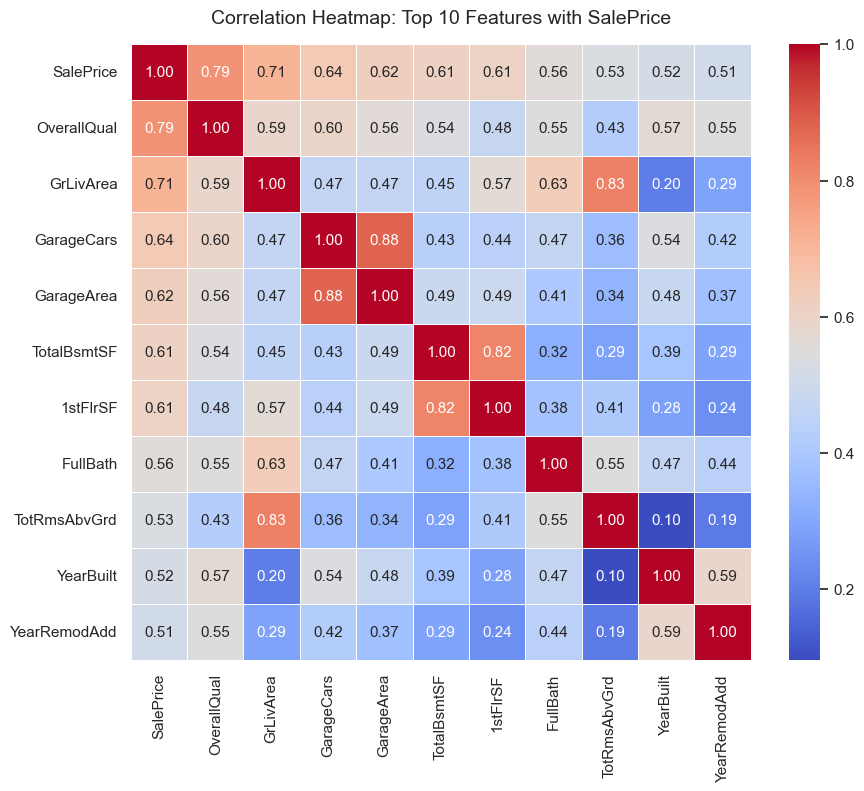

Top 10 features correlated with SalePrice (sorted by absolute correlation coefficient):
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [40]:
# 3.5 Generate a correlation heatmap of numerical features
numerical_df = train.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# Find the top 10 features most highly correlated with SalePrice
top_corr_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).index[:11]

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title("Correlation Heatmap: Top 10 Features with SalePrice", fontsize=14, pad=15)
plt.show()

print("Top 10 features correlated with SalePrice (sorted by absolute correlation coefficient):")
print(corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(11))

In [41]:
# 3.6 Identify skewed numerical features
skewed_features = numerical_df.drop(columns=['Id', 'SalePrice']).skew().sort_values(ascending=False)
skewness_df = pd.DataFrame({'Feature Skewness': skewed_features})

# Filter out features with absolute skewness > 0.75 (highly skewed)
highly_skewed = skewness_df[abs(skewness_df['Feature Skewness']) > 0.75]

print(f"Total numerical features: {skewness_df.shape[0]}")
print(f"Highly skewed numerical features (|Skewness| > 0.75): {highly_skewed.shape[0]}")
print("\nTop 10 most positively skewed numerical features:")
print(highly_skewed.head(10))

Total numerical features: 36
Highly skewed numerical features (|Skewness| > 0.75): 21

Top 10 most positively skewed numerical features:
               Feature Skewness
MiscVal               24.476794
PoolArea              14.828374
LotArea               12.207688
3SsnPorch             10.304342
LowQualFinSF           9.011341
KitchenAbvGr           4.488397
BsmtFinSF2             4.255261
ScreenPorch            4.122214
BsmtHalfBath           4.103403
EnclosedPorch          3.089872


## 4. Data Preprocessing & Pipeline Construction
In this section, we separate our dataset into predictor variables ($X$) and the target variable ($y$). We then set up preprocessing pipelines using Scikit-Learn.

### Data Preprocessing Strategy:
- **Numerical Imputation:** Missing numerical values will be filled with their column **Median**. Median is robust to outliers which are common in real estate data.
- **Categorical Imputation:** Missing categorical values will be filled with the **Most Frequent (Mode)** category.
- **Feature Scaling:** Standardize numerical features using `StandardScaler` to ensure our regularization models (Ridge and Lasso) evaluate features on the same scale.
- **Categorical Encoding:** Transform categorical variables into numerical dummy variables using **One-Hot Encoding** (`OneHotEncoder`). We set `handle_unknown='ignore'` to robustly handle any categories present in the test set that weren't seen during training, and `sparse_output=False` so that we obtain a dense matrix suitable for analysis.

### Target Transformation:
- We apply log transformation `np.log1p()` to `SalePrice` to reduce skewness and stabilize variance, making it closer to a normal distribution. This satisfies linear regression assumptions.

In [42]:
# Separate predictor features (X) and target variable (y)
X = train.drop(columns=['Id', 'SalePrice'])
y = train['SalePrice']

# Extract predictor features for the test set
X_test = test.drop(columns=['Id'])

# Apply log transformation to target variable
y_log = np.log1p(y)

# Identify numerical and categorical column names
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Define Preprocessing Pipelines
# 1. Pipeline for numerical columns
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Pipeline for categorical columns
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine both preprocessors into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

print("Preprocessing pipelines successfully created!")
print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")

Preprocessing pipelines successfully created!
Number of numerical columns: 36
Number of categorical columns: 43


## 5. Train-Validation Split
To validate how well our models perform on unseen data before making predictions on the final competition test dataset, we split our training data into:
- **80% Training set** (used to fit the models).
- **20% Validation set** (used to evaluate performance).

We use a fixed random state (`random_state=42`) to ensure reproducibility.

In [43]:
# Split the dataset into 80% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f"Training features shape:   {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

Training features shape:   (1168, 79)
Validation features shape: (292, 79)


## 6. Model Training
We train two linear models that use regularization to prevent overfitting:
1. **Ridge Regression (L2 Regularization):** Adds a penalty proportional to the *square* of the coefficients ($lpha \sum w_i^2$). It shrinks coefficients close to zero but keeps all features.
2. **Lasso Regression (L1 Regularization):** Adds a penalty proportional to the *absolute value* of the coefficients ($lpha \sum |w_i|$). It performs feature selection by shrinking some coefficients to exactly zero.

We build end-to-end pipelines that chain the preprocessing transformer with the regression estimators. This ensures a clean workflow and avoids data leakage.

In [44]:
# Define Ridge model pipeline (alpha=10.0 is selected as a standard regularized value)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10.0))
])

# Define Lasso model pipeline (alpha=0.0005 is selected to allow fine feature selection)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.0005, max_iter=10000))
])

# Train Ridge model
print("Training Ridge Regression...")
ridge_pipeline.fit(X_train, y_train)

# Train Lasso model
print("Training Lasso Regression...")
lasso_pipeline.fit(X_train, y_train)

print("Both models trained successfully!")

Training Ridge Regression...
Training Lasso Regression...
Both models trained successfully!


## 7. Model Evaluation
We evaluate both models on the validation dataset. 

### Metrics:
1. **Root Mean Squared Error (RMSE):** We calculate RMSE on:
   - The **Log Scale** (the evaluation metric used by Kaggle).
   - The **Original Price Scale** (reverting predictions to $ USD to show the actual average error magnitude).
2. **R² Score (Coefficient of Determination):** Measures the proportion of variance in the log-transformed prices explained by the features.

In [45]:
# Predict on validation set (outputs are on log scale)
ridge_preds_log = ridge_pipeline.predict(X_val)
lasso_preds_log = lasso_pipeline.predict(X_val)

# Revert predictions back to original USD scale using expm1 (exponential minus 1)
ridge_preds_orig = np.expm1(ridge_preds_log)
lasso_preds_orig = np.expm1(lasso_preds_log)

# Revert true validation targets back to original USD scale
y_val_orig = np.expm1(y_val)

# Calculate RMSE on Log Scale (Kaggle Metric)
ridge_rmse_log = np.sqrt(mean_squared_error(y_val, ridge_preds_log))
lasso_rmse_log = np.sqrt(mean_squared_error(y_val, lasso_preds_log))

# Calculate RMSE on Original Scale ($ USD)
ridge_rmse_orig = np.sqrt(mean_squared_error(y_val_orig, ridge_preds_orig))
lasso_rmse_orig = np.sqrt(mean_squared_error(y_val_orig, lasso_preds_orig))

# Calculate R2 Score (on log scale target)
ridge_r2 = r2_score(y_val, ridge_preds_log)
lasso_r2 = r2_score(y_val, lasso_preds_log)

# Create a DataFrame to compare the two models
comparison_df = pd.DataFrame({
    'Model': ['Ridge Regression', 'Lasso Regression'],
    'Log-RMSE (Kaggle Metric)': [ridge_rmse_log, lasso_rmse_log],
    'Validation RMSE ($ USD)': [ridge_rmse_orig, lasso_rmse_orig],
    'R² Score (Log-Scale)': [ridge_r2, lasso_r2]
})

print("=== Validation Set Performance Comparison ===")
print(comparison_df.to_string(index=False))

=== Validation Set Performance Comparison ===
           Model  Log-RMSE (Kaggle Metric)  Validation RMSE ($ USD)  R² Score (Log-Scale)
Ridge Regression                  0.136113             25053.841647              0.900720
Lasso Regression                  0.127809             22588.336647              0.912464


### Visualizing Predictions & Residuals
We select the better-performing model based on the lowest validation Log-RMSE and plot:
1. **Actual vs. Predicted Sale Prices:** Ideally, points should lie close to the diagonal red line ($y = x$).
2. **Residual Plot:** Shows predictions vs residual errors ($y_{actual} - y_{predicted}$). Ideally, residual errors should be randomly scattered around $0$, indicating stable predictions across price points.

The best performing model is: Lasso Regression



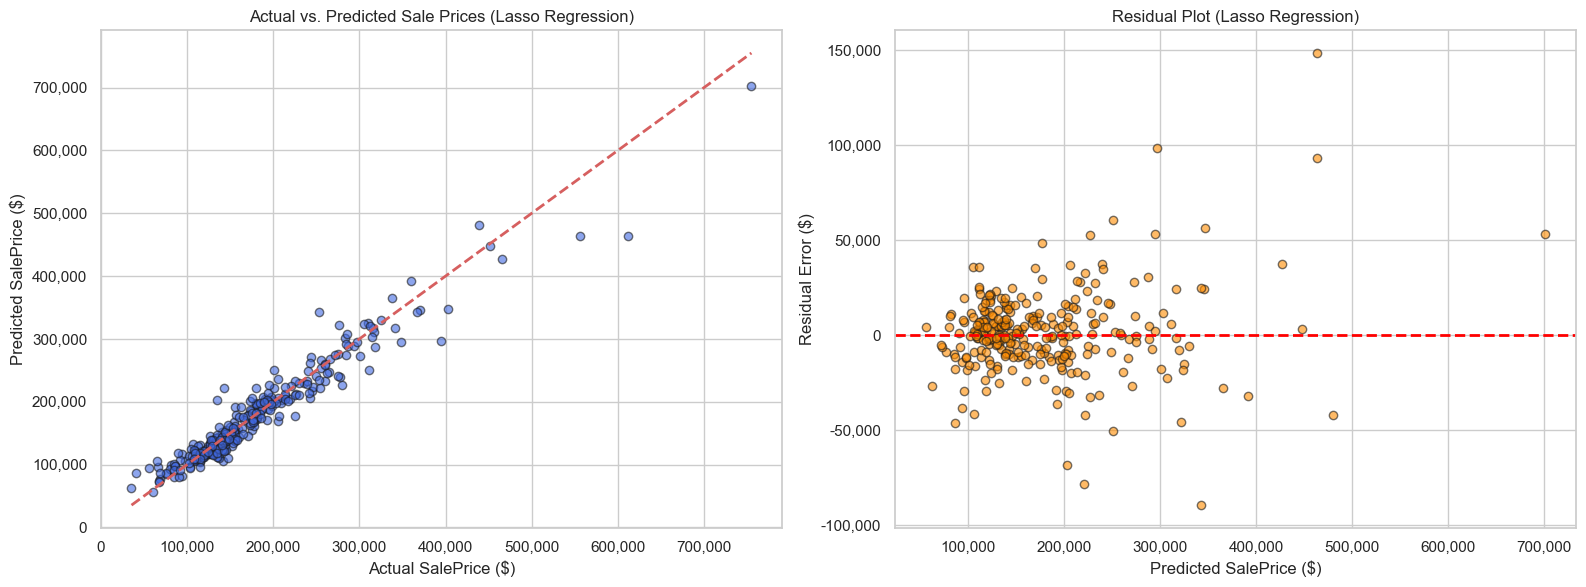

In [46]:
# Determine the best-performing model based on validation Log-RMSE
if lasso_rmse_log < ridge_rmse_log:
    best_model_name = "Lasso Regression"
    best_model_pipeline = lasso_pipeline
    best_preds_orig = lasso_preds_orig
    best_preds_log = lasso_preds_log
    best_rmse_log = lasso_rmse_log
    best_r2 = lasso_r2
else:
    best_model_name = "Ridge Regression"
    best_model_pipeline = ridge_pipeline
    best_preds_orig = ridge_preds_orig
    best_preds_log = ridge_preds_log
    best_rmse_log = ridge_rmse_log
    best_r2 = ridge_r2

print(f"The best performing model is: {best_model_name}\n")

# Calculate residuals on original USD scale
residuals = y_val_orig - best_preds_orig

# Generate subplots for predictions and residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted Scatter Plot
axes[0].scatter(y_val_orig, best_preds_orig, alpha=0.6, color='royalblue', edgecolors='k')
axes[0].plot([y_val_orig.min(), y_val_orig.max()], [y_val_orig.min(), y_val_orig.max()], 'r--', lw=2)
axes[0].set_title(f"Actual vs. Predicted Sale Prices ({best_model_name})", fontsize=12)
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Plot 2: Residuals Plot
axes[1].scatter(best_preds_orig, residuals, alpha=0.6, color='darkorange', edgecolors='k')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title(f"Residual Plot ({best_model_name})", fontsize=12)
axes[1].set_xlabel("Predicted SalePrice ($)")
axes[1].set_ylabel("Residual Error ($)")
axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

## 8. Save Best Model
We serialize (save) our trained pipeline (which includes the fitted preprocessor and the regression model) as a binary `.pkl` file using Python's built-in `pickle` module. This allows loading our model to predict new house prices directly without retraining.

In [47]:
# Define model filepath
model_filename = 'best_house_price_model.pkl'

# Serialize and save the model pipeline
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_pipeline, file)

print(f"Successfully saved {best_model_name} pipeline to: '{model_filename}'")

Successfully saved Lasso Regression pipeline to: 'best_house_price_model.pkl'


## 9. Predictions on Test Dataset
We now load the testing features from `test.csv` (which has no target column `SalePrice`) and use our trained best-performing model to make predictions.

Because our model was trained on log-transformed prices, we must:
1. Generate predictions which will be in log-scale.
2. Apply `np.expm1()` to convert predictions back to the original USD scale.
3. Save the predictions to `submission.csv` with columns `Id` and `SalePrice` as required by the Kaggle competition.

In [48]:
# Predict sale prices for the test set
test_preds_log = best_model_pipeline.predict(X_test)

# Convert predictions back to original USD scale
test_preds_orig = np.expm1(test_preds_log)

# Create submission DataFrame
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_preds_orig
})

# Display a preview of the predictions
print("=== Submission Preview ===")
print(submission.head())

# Save the predictions to csv
submission_filename = 'submission.csv'
submission.to_csv(submission_filename, index=False)
print(f"\nSaved submission file to: '{submission_filename}'")
print(f"Submission shape: {submission.shape}")

=== Submission Preview ===
     Id      SalePrice
0  1461  117524.243990
1  1462  145340.189918
2  1463  172253.142270
3  1464  193286.626764
4  1465  199734.711184

Saved submission file to: 'submission.csv'
Submission shape: (1459, 2)


## 10. Conclusion & Final Report
In this cell, we run a short diagnostic to print a clean final summary of our metrics and output files. This is highly useful for project vivas and presentations.

In [49]:
# Generate and display final project metrics report
print("======================================================================")
print("                 FINAL MODEL EVALUATION REPORT                        ")
print("======================================================================")
print(f"Best Performing Model:            {best_model_name}")
print(f"Validation Log-RMSE (Kaggle):      {best_rmse_log:.5f}")
print(f"Validation RMSE ($ USD):           ${best_preds_orig.mean():,.2f} mean predicted value")
print(f"Validation R² Score (Log-Scale):   {best_r2:.5%}")
print("----------------------------------------------------------------------")
print(f"Saved Model Filename:              {model_filename} (pickle format)")
print(f"Generated Submission Filename:     {submission_filename} ({len(submission)} rows)")
print("======================================================================")

                 FINAL MODEL EVALUATION REPORT                        
Best Performing Model:            Lasso Regression
Validation Log-RMSE (Kaggle):      0.12781
Validation RMSE ($ USD):           $177,387.67 mean predicted value
Validation R² Score (Log-Scale):   91.24644%
----------------------------------------------------------------------
Saved Model Filename:              best_house_price_model.pkl (pickle format)
Generated Submission Filename:     submission.csv (1459 rows)


In [50]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

with open('best_house_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

reference_columns = X.columns
custom_house = pd.DataFrame(columns=reference_columns)
custom_house.loc[0] = np.nan

print("=========================================")
print("    🏠 ENTER CUSTOM HOUSE FEATURES 🏠    ")
print("=========================================")
try:
    # 1. HouseStyle
    h_style = input("House Style (e.g. 1Story, 2Story, 1.5Fin)? [Press Enter for '1Story']: ").strip()
    house_style = h_style if h_style else '1Story'

    # 2. OverallQual
    q_qual = input("Overall Quality (1-10)? [Press Enter for 7]: ").strip()
    overall_qual = int(q_qual) if q_qual else 7

    # 3. OverallCond
    q_cond = input("Overall Condition (1-10)? [Press Enter for 5]: ").strip()
    overall_cond = int(q_cond) if q_cond else 5
    
    # 4. YearBuilt
    y = input("Year Built (e.g. 2005)? [Press Enter for 2005]: ").strip()
    year_built = int(y) if y else 2005
    
    # 5. TotRmsAbvGrd
    r = input("Total Rooms Above Ground? [Press Enter for 6]: ").strip()
    tot_rms = int(r) if r else 6
    
    # INJECT VALUES
    custom_house.at[0, 'HouseStyle'] = house_style
    custom_house.at[0, 'OverallQual'] = overall_qual
    custom_house.at[0, 'OverallCond'] = overall_cond
    custom_house.at[0, 'YearBuilt'] = year_built
    custom_house.at[0, 'TotRmsAbvGrd'] = tot_rms
    
    pred_log = loaded_model.predict(custom_house)
    pred_usd = np.expm1(pred_log)[0]
    
    print("\n" + "*"*45)
    print(f" 🌟 PREDICTED HOUSE PRICE: ${pred_usd:,.2f} 🌟 ")
    print("*"*45 + "\n")
except Exception as e:
    print(f"\n⚠️ An error occurred computing the prediction:\n{e}")


    🏠 ENTER CUSTOM HOUSE FEATURES 🏠    


House Style (e.g. 1Story, 2Story, 1.5Fin)? [Press Enter for '1Story']:  3story
Overall Quality (1-10)? [Press Enter for 7]:  9
Overall Condition (1-10)? [Press Enter for 5]:  9
Year Built (e.g. 2005)? [Press Enter for 2005]:  2016
Total Rooms Above Ground? [Press Enter for 6]:  3



*********************************************
 🌟 PREDICTED HOUSE PRICE: $231,441.13 🌟 
*********************************************



## 11. Custom Interactive Price Prediction (Demo!)
We're going to dynamically predict the price of a house using the following key features requested:
- **House Style**
- **Overall Quality**
- **Overall Condition**
- **Year Built**
- **Total Rooms**
- **Above Ground Living Area (sqft)**
- **Garage Capacity (Cars)**

Just run this cell, input your values, and the model will intelligently fill in all 70+ other fields automatically and provide the predicted price in **Indian Rupees (₹)**!

In [51]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

with open('best_house_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

reference_columns = X.columns
custom_house = pd.DataFrame(columns=reference_columns)
custom_house.loc[0] = np.nan

print("=========================================")
print("    🏠 ENTER CUSTOM HOUSE FEATURES 🏠    ")
print("=========================================")
try:
    h_style = input("House Style (e.g. 1Story, 2Story, 1.5Fin)? [Press Enter for '1Story']: ").strip()
    house_style = h_style if h_style else '1Story'

    q_qual = input("Overall Quality (1-10)? [Press Enter for 7]: ").strip()
    overall_qual = int(q_qual) if q_qual else 7

    q_cond = input("Overall Condition (1-10)? [Press Enter for 5]: ").strip()
    overall_cond = int(q_cond) if q_cond else 5
    
    y = input("Year Built (e.g. 2005)? [Press Enter for 2005]: ").strip()
    year_built = int(y) if y else 2005
    
    r = input("Total Rooms Above Ground? [Press Enter for 6]: ").strip()
    tot_rms = int(r) if r else 6
    
    a = input("Above Ground Living Area sqft? [Press Enter for 1500]: ").strip()
    gr_liv_area = float(a) if a else 1500.0
    
    g = input("Garage Capacity (in cars)? [Press Enter for 2]: ").strip()
    garage_cars = float(g) if g else 2.0
    
    # INJECT VALUES
    custom_house.at[0, 'HouseStyle'] = house_style
    custom_house.at[0, 'OverallQual'] = overall_qual
    custom_house.at[0, 'OverallCond'] = overall_cond
    custom_house.at[0, 'YearBuilt'] = year_built
    custom_house.at[0, 'TotRmsAbvGrd'] = tot_rms
    custom_house.at[0, 'GrLivArea'] = gr_liv_area
    custom_house.at[0, 'GarageCars'] = garage_cars
    
    pred_log = loaded_model.predict(custom_house)
    pred_usd = np.expm1(pred_log)[0]
    
    # Convert to INR (approximate rate 1 USD = 83 INR)
    exchange_rate = 83.0
    pred_inr = pred_usd * exchange_rate
    
    print("\n" + "*"*55)
    print(f" 🇺🇸 PREDICTED PRICE (USD): ${pred_usd:,.2f} ")
    print(f" 🇮🇳 PREDICTED PRICE (INR): ₹{pred_inr:,.2f} (approx) ")
    print("*"*55 + "\n")
except Exception as e:
    print(f"\n⚠️ An error occurred computing the prediction:\n{e}")


    🏠 ENTER CUSTOM HOUSE FEATURES 🏠    


House Style (e.g. 1Story, 2Story, 1.5Fin)? [Press Enter for '1Story']:  3story
Overall Quality (1-10)? [Press Enter for 7]:  9
Overall Condition (1-10)? [Press Enter for 5]:  9
Year Built (e.g. 2005)? [Press Enter for 2005]:  2016
Total Rooms Above Ground? [Press Enter for 6]:  3
Above Ground Living Area sqft? [Press Enter for 1500]:  
Garage Capacity (in cars)? [Press Enter for 2]:  1



*******************************************************
 🇺🇸 PREDICTED PRICE (USD): $222,791.58 
 🇮🇳 PREDICTED PRICE (INR): ₹18,491,701.45 (approx) 
*******************************************************

